# Part 1

In [6]:
import numpy as np
from keras.datasets import cifar10
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.decomposition import PCA
import random 
import matplotlib.pyplot as plt


## k-means clustering: From the CIFAR-10 dataset set

In [7]:


(X_train, y_train), (X_test, y_test) = cifar10.load_data() 

X_train = X_train.reshape(X_train.shape[0], -1) # Reshape to 2D array
X_train = X_train.astype('float32') / 255.0 # Normalize data

kmeans = KMeans(n_clusters=10, random_state=0, n_init=10) # Initialize KMeans with 10 clusters
kmeans.fit(X_train)
y_pred = kmeans.predict(X_train)

score = adjusted_rand_score(y_train.flatten(), y_pred)
print(f"Adjusted Rand Index: {score}")



Adjusted Rand Index: 0.04174420235350119


In [13]:

# Flatten labels
true_labels = y_train.flatten()

# Create empty 10x10 table
table = np.zeros((10,10), dtype=int)

# Count occurrences
for true, cluster in zip(true_labels, y_pred):
    table[true][cluster] += 1

# Convert to DataFrame for nicer display
df = pd.DataFrame(table,
                  index=[f"class_{i}" for i in range(10)],
                  columns=[f"cluster_{i}" for i in range(10)])

print(df)

         cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  \
class_0        131        789        973        386        222        236   
class_1        411        493        148        406        489        744   
class_2        349        179        520        310        594        918   
class_3        775        126        471        379        703        701   
class_4        949        189        326        166        602       1020   
class_5        865         90        612        271        578        565   
class_6        475         43        146        373       1080       1207   
class_7        747        209        306        558        315        654   
class_8        213       1590        514        177        194        173   
class_9        157        758        137        582        144        520   

         cluster_6  cluster_7  cluster_8  cluster_9  
class_0        487        545        941        290  
class_1        827        863        213    

## Compute Accuracy

In [14]:
# Convert to numpy if using dataframe
matrix = df.values

# For each cluster (column), get the dominant class count
correct = np.sum(np.max(matrix, axis=0))

total = np.sum(matrix)

accuracy = correct / total

print("Clustering Accuracy:", accuracy)

Clustering Accuracy: 0.22126


# Part 2

### Load CIFAR Images

In [11]:


# CIFAR-10 images are [0,1] floats with ToTensor()
transform = transforms.ToTensor()

cifar_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

targets = np.array(cifar_train.targets)

# pick 100 indices per class
indices = []
per_class = 100
for c in range(10):
    cls_idx = np.where(targets == c)[0][:per_class]
    indices.extend(cls_idx.tolist())

subset = Subset(cifar_train, indices)
loader = DataLoader(subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

print("Subset size:", len(subset)) 

Subset size: 1000


### Autoencoder

In [7]:

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder: 3x32x32 -> latent_dim
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 32x16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),# 128x4x4
            nn.ReLU(),
        )
        self.enc_fc = nn.Linear(128 * 4 * 4, latent_dim)

        # Decoder: latent_dim -> 3x32x32
        self.dec_fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # 3x32x32
            nn.Sigmoid(), 
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        z = self.enc_fc(h)
        return z

    def forward(self, x):
        z = self.encode(x)
        h = self.dec_fc(z).view(-1, 128, 4, 4)
        out = self.dec(h)
        return out

### Train

In [5]:
import torch.optim as optim

def train(model, loader, epochs=10, lr=1e-3, device=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.to(device)
    model.train()

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    for epoch in range(1, epochs + 1):
        running = 0.0
        n = 0

        for x, _ in loader:
            x = x.to(device)

            recon = model(x)
            loss = criterion(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running += loss.item() * x.size(0)
            n += x.size(0)

        print(f"Epoch {epoch}/{epochs} | Loss: {running/n:.6f}")

    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
ae = Autoencoder(latent_dim=128)
ae = train(ae, loader, epochs=10, lr=1e-3, device=device)

/Users/jadsaad/Deep Learning/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/10 | Loss: 0.062542
Epoch 2/10 | Loss: 0.054083
Epoch 3/10 | Loss: 0.040370
Epoch 4/10 | Loss: 0.033139
Epoch 5/10 | Loss: 0.030002
Epoch 6/10 | Loss: 0.028301
Epoch 7/10 | Loss: 0.026563
Epoch 8/10 | Loss: 0.025445
Epoch 9/10 | Loss: 0.024153
Epoch 10/10 | Loss: 0.023149


### Extract features to run K-means

In [11]:
features = []
labels = []

ae.eval()

with torch.no_grad():
    for x, y in loader:
        z = ae.encode(x)              # encoder output
        z = z.view(z.size(0), -1)         # flatten feature maps
        features.append(z.numpy())
        labels.append(y.numpy())

features = np.concatenate(features)
labels = np.concatenate(labels)

### Produce Tables

In [12]:
kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)

clusters = kmeans.fit_predict(features)

### Table

In [13]:
df = pd.DataFrame(table, index=range(10), columns=range(10))
print(df)

    0   1   2   3   4   5   6   7   8   9
0  14   5   7   1   2   4  16  26  10  15
1  10  11  19   3  12  11  24   1   6   3
2   3  19  20  10   4   5   7  26   1   5
3   2  16  15   7   8  20  11   8   6   7
4   3  19  18   9  18   9  12   8   3   1
5   0  18   6  12  13  30   8  11   1   1
6   1  22  20  13  11  11   8  10   2   2
7   2  23  11   6  13   9  11   7  17   1
8  25   7   7   1   5   6  33  11   5   0
9  15  13  15   1   3   1  15   6  31   0


In [14]:
correct = np.sum(np.max(table, axis=0))
total = np.sum(table)

accuracy = correct / total
print("Clustering accuracy:", accuracy)

Clustering accuracy: 0.234


### Run PCA

In [16]:

pca = PCA(n_components=10)

features_pca = pca.fit_transform(features)
kmeans_pca = KMeans(n_clusters=10, random_state=0, n_init=10)

clusters_pca = kmeans_pca.fit_predict(features_pca)
table_pca = np.zeros((10,10), dtype=int)

for true_label, cluster_label in zip(labels, clusters_pca):
    table_pca[true_label][cluster_label] += 1

print(pd.DataFrame(table_pca))

    0   1   2   3   4   5   6   7   8   9
0   9   6   2   1  15  14  17  26   4   6
1   7  10  11   2   3  23  10   2  12  20
2   1  22   4  10   5   8   3  26   4  17
3   6  17   7   7   6  11   2   9  20  15
4   3  22  16   7   2  12   2   8   9  19
5   0  19  13  12   1   8   1  11  29   6
6   2  25  10  11   2   7   1  10  11  21
7  19  25  11   4   1  10   2   7  10  11
8   5   8   5   0   1  32  25  11   6   7
9  30  14   3   1   0  14  16   7   1  14


# Part 3

In [14]:

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Keep constant corruption ratio and add noise

In [15]:

def add_noise(img, noise_ratio=0.1):
    
    noisy = img.copy()
    h, w = noisy.shape

    total_pixels = h * w
    corrupted = int(total_pixels * noise_ratio)

    for i in range(corrupted):
        y = random.randint(0, h - 1)
        x = random.randint(0, w - 1)
        noisy[y][x] = 255

    for i in range(corrupted):
        y = random.randint(0, h - 1)
        x = random.randint(0, w - 1)
        noisy[y][x] = 0

    return noisy

def add_noise_cifar(img, noise_ratio):

    img = img.copy()

    for c in range(3):
        img[:,:,c] = add_noise(img[:,:,c], noise_ratio)

    return img

## Create noisy data

In [16]:
transform = transforms.ToTensor()

cifar_train = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

indices = np.random.choice(len(cifar_train), 5000, replace=False)
subset = torch.utils.data.Subset(cifar_train, indices)

## Train Func

In [21]:
def train_denoising(model, loader, noise_ratio=0.1, epochs=30):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0
        total_samples = 0

        for x, _ in loader:
            clean = x.to(device)

            noisy_list = []
            for i in range(clean.size(0)):
                np_img = (clean[i].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
                noisy_np = add_noise_cifar(np_img, noise_ratio)

                noisy_t = torch.from_numpy(noisy_np).permute(2,0,1).float() / 255.0
                noisy_list.append(noisy_t)

            noisy = torch.stack(noisy_list).to(device)

            recon = model(noisy)
            loss = criterion(recon, clean)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate loss correctly
            batch_size = clean.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        print(f"Epoch {epoch+1}, Loss: {total_loss/total_samples:.6f}")

## Test Func

In [40]:
def show_results(model, dataset, noise_ratio, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    fig, axes = plt.subplots(10, 3, figsize=(7, 20))

    for i in range(10):
        img, _ = dataset[i]  

        # make uint8 image for noise injection
        clean_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
        noisy_np = add_noise_cifar(clean_np, noise_ratio)

        # float32 tensor in [0,1] for model
        noisy_tensor = torch.from_numpy(noisy_np).permute(2,0,1).float().unsqueeze(0) / 255.0
        noisy_tensor = noisy_tensor.to(device)

        with torch.no_grad():
            denoised = model(noisy_tensor)[0].cpu()  

        axes[i,0].imshow(img.permute(1,2,0))
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(noisy_np)
        axes[i,1].set_title("Noisy")
        axes[i,1].axis("off")

        axes[i,2].imshow(denoised.permute(1,2,0).clamp(0,1))
        axes[i,2].set_title("Denoised")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

## Run with 5 diff noise levels

Training with noise: 0.05
Epoch 1, Loss: 0.061490
Epoch 2, Loss: 0.046766
Epoch 3, Loss: 0.036134
Epoch 4, Loss: 0.031768
Epoch 5, Loss: 0.028471
Epoch 6, Loss: 0.026500
Epoch 7, Loss: 0.025182
Epoch 8, Loss: 0.023980
Epoch 9, Loss: 0.023208
Epoch 10, Loss: 0.022145
Epoch 11, Loss: 0.021248
Epoch 12, Loss: 0.020555
Epoch 13, Loss: 0.019911
Epoch 14, Loss: 0.019249
Epoch 15, Loss: 0.018906
Epoch 16, Loss: 0.018169
Epoch 17, Loss: 0.017523
Epoch 18, Loss: 0.016479
Epoch 19, Loss: 0.015796
Epoch 20, Loss: 0.015088
Epoch 21, Loss: 0.014594
Epoch 22, Loss: 0.014147
Epoch 23, Loss: 0.013745
Epoch 24, Loss: 0.013429
Epoch 25, Loss: 0.013023
Epoch 26, Loss: 0.012713
Epoch 27, Loss: 0.012628
Epoch 28, Loss: 0.012157
Epoch 29, Loss: 0.012002
Epoch 30, Loss: 0.011633


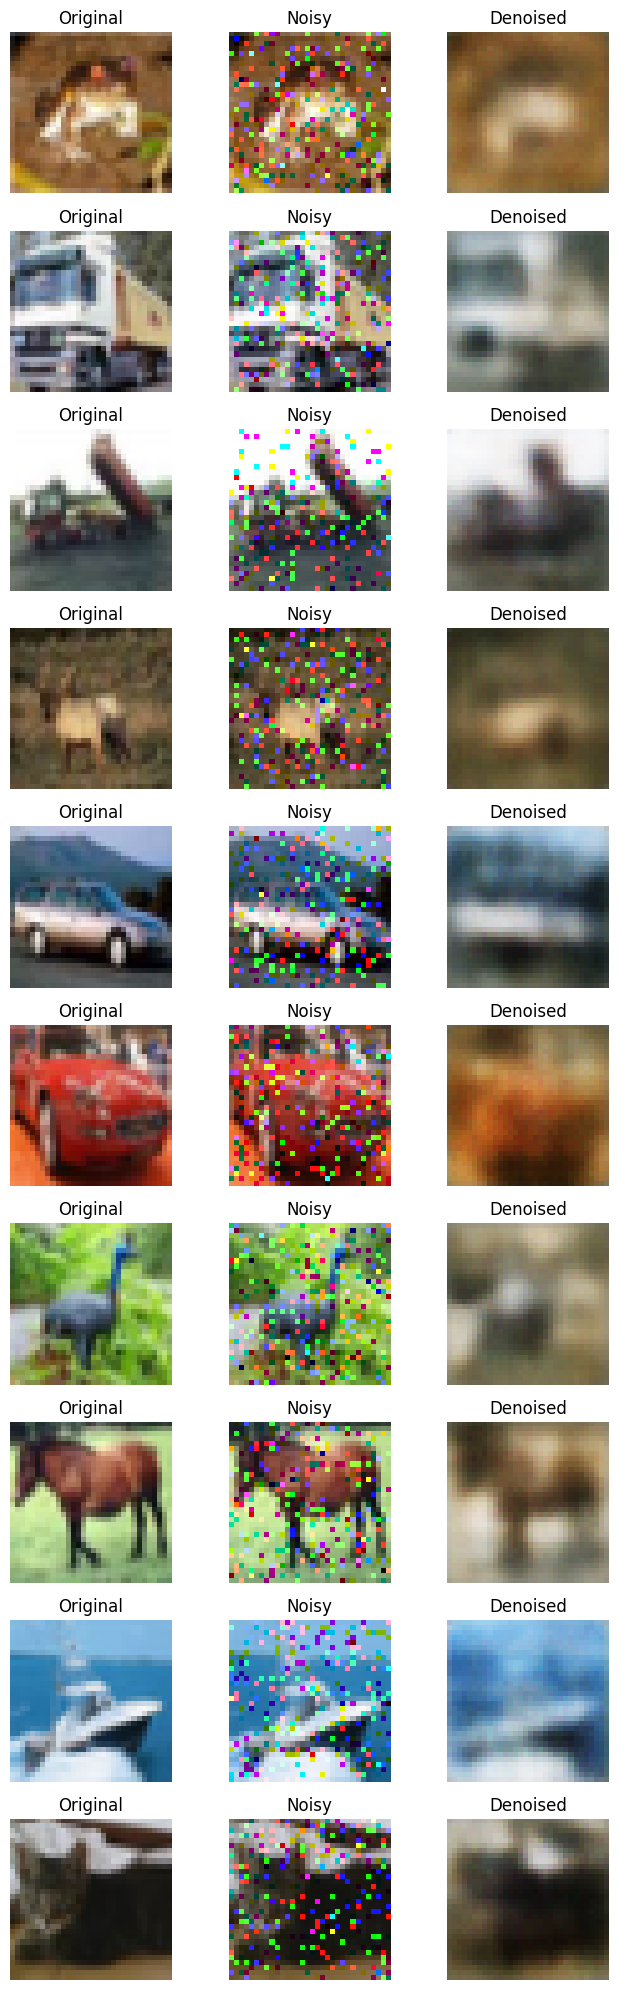

Training with noise: 0.1
Epoch 1, Loss: 0.030912
Epoch 2, Loss: 0.015845
Epoch 3, Loss: 0.013254
Epoch 4, Loss: 0.012454
Epoch 5, Loss: 0.012077
Epoch 6, Loss: 0.011884
Epoch 7, Loss: 0.011711
Epoch 8, Loss: 0.011595
Epoch 9, Loss: 0.011487
Epoch 10, Loss: 0.011419
Epoch 11, Loss: 0.011303
Epoch 12, Loss: 0.011243
Epoch 13, Loss: 0.011115
Epoch 14, Loss: 0.011035
Epoch 15, Loss: 0.010923
Epoch 16, Loss: 0.010820
Epoch 17, Loss: 0.010763
Epoch 18, Loss: 0.010719
Epoch 19, Loss: 0.010596
Epoch 20, Loss: 0.010517
Epoch 21, Loss: 0.010428
Epoch 22, Loss: 0.010342
Epoch 23, Loss: 0.010298
Epoch 24, Loss: 0.010156
Epoch 25, Loss: 0.010092
Epoch 26, Loss: 0.009991
Epoch 27, Loss: 0.009891
Epoch 28, Loss: 0.009797
Epoch 29, Loss: 0.009758
Epoch 30, Loss: 0.009637


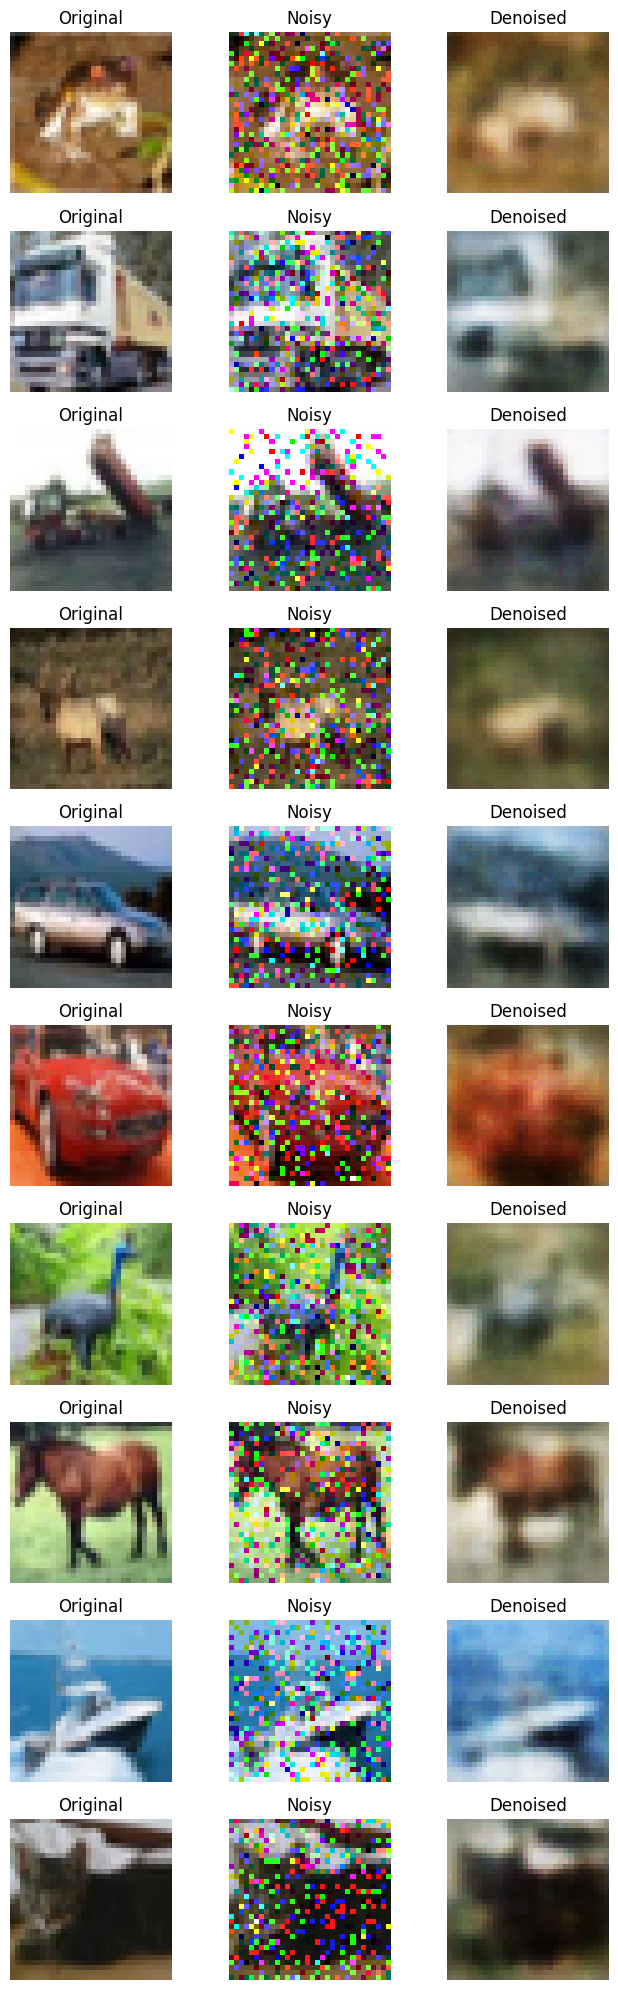

Training with noise: 0.2
Epoch 1, Loss: 0.034317
Epoch 2, Loss: 0.016709
Epoch 3, Loss: 0.013090
Epoch 4, Loss: 0.012062
Epoch 5, Loss: 0.011633
Epoch 6, Loss: 0.011365
Epoch 7, Loss: 0.011252
Epoch 8, Loss: 0.011160
Epoch 9, Loss: 0.011049
Epoch 10, Loss: 0.010953
Epoch 11, Loss: 0.010945
Epoch 12, Loss: 0.010900
Epoch 13, Loss: 0.010829
Epoch 14, Loss: 0.010805
Epoch 15, Loss: 0.010735
Epoch 16, Loss: 0.010687
Epoch 17, Loss: 0.010663
Epoch 18, Loss: 0.010612
Epoch 19, Loss: 0.010536
Epoch 20, Loss: 0.010499
Epoch 21, Loss: 0.010427
Epoch 22, Loss: 0.010381
Epoch 23, Loss: 0.010362
Epoch 24, Loss: 0.010390
Epoch 25, Loss: 0.010270
Epoch 26, Loss: 0.010227
Epoch 27, Loss: 0.010204
Epoch 28, Loss: 0.010186
Epoch 29, Loss: 0.010043
Epoch 30, Loss: 0.009996


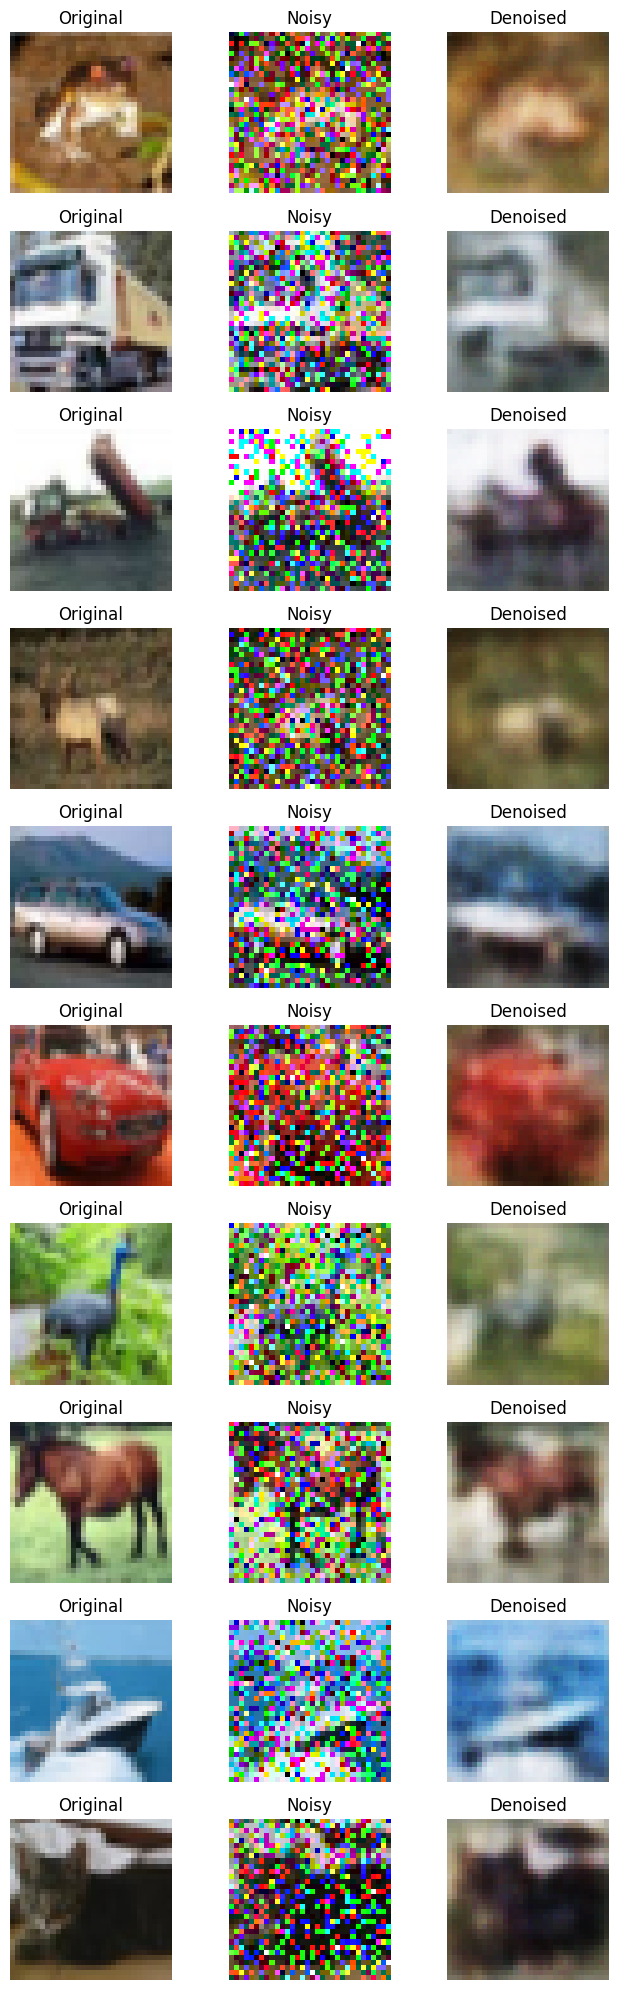

Training with noise: 0.3
Epoch 1, Loss: 0.034773
Epoch 2, Loss: 0.017986
Epoch 3, Loss: 0.014775
Epoch 4, Loss: 0.013169
Epoch 5, Loss: 0.012538
Epoch 6, Loss: 0.012272
Epoch 7, Loss: 0.012157
Epoch 8, Loss: 0.012003
Epoch 9, Loss: 0.011932
Epoch 10, Loss: 0.011852
Epoch 11, Loss: 0.011834
Epoch 12, Loss: 0.011747
Epoch 13, Loss: 0.011771
Epoch 14, Loss: 0.011669
Epoch 15, Loss: 0.011628
Epoch 16, Loss: 0.011650
Epoch 17, Loss: 0.011613
Epoch 18, Loss: 0.011574
Epoch 19, Loss: 0.011512
Epoch 20, Loss: 0.011436
Epoch 21, Loss: 0.011410
Epoch 22, Loss: 0.011426
Epoch 23, Loss: 0.011315
Epoch 24, Loss: 0.011359
Epoch 25, Loss: 0.011311
Epoch 26, Loss: 0.011256
Epoch 27, Loss: 0.011200
Epoch 28, Loss: 0.011280
Epoch 29, Loss: 0.011132
Epoch 30, Loss: 0.011115


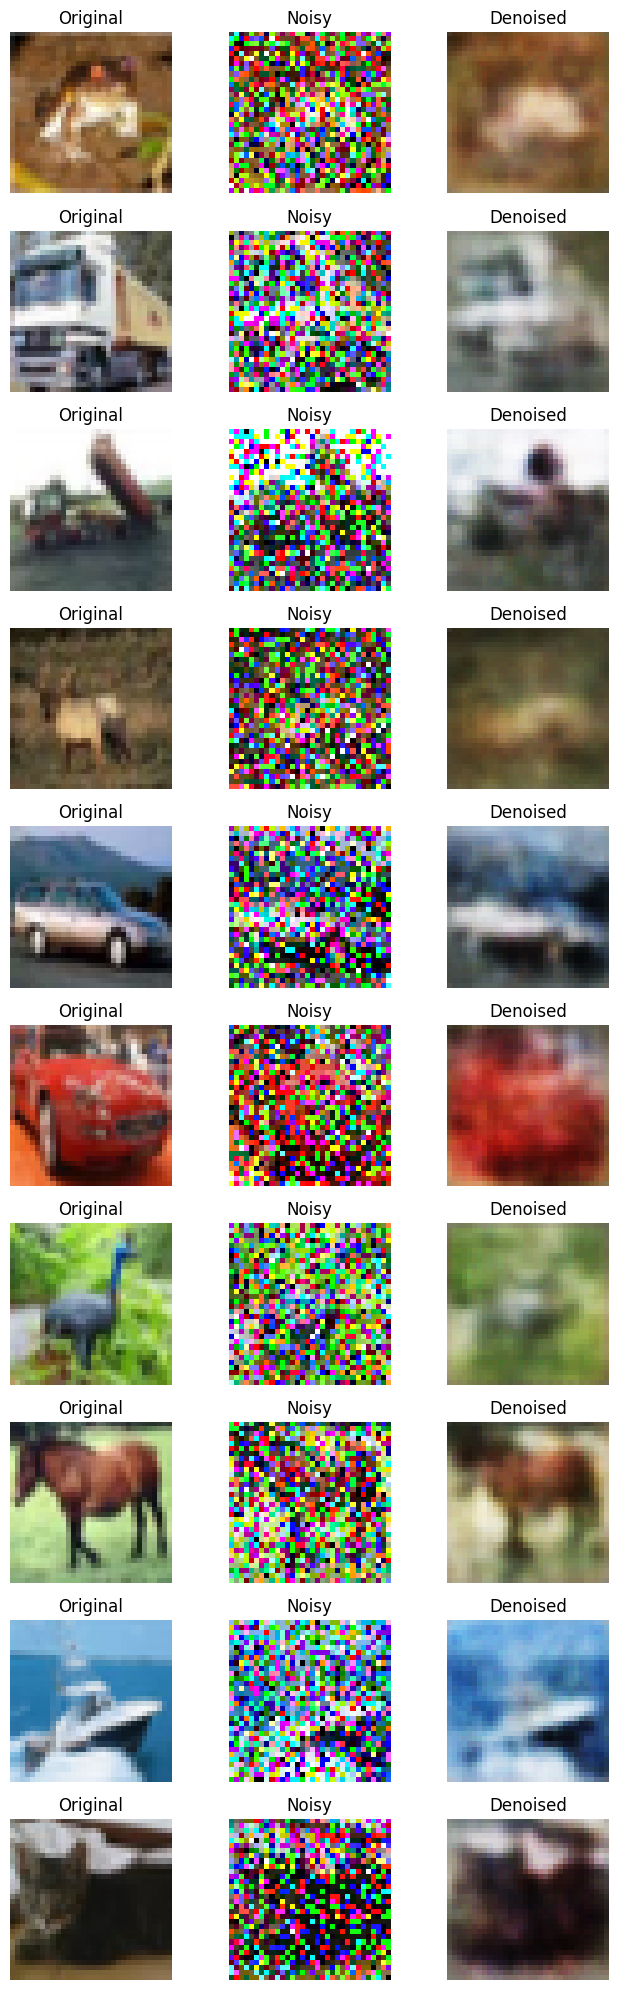

Training with noise: 0.4
Epoch 1, Loss: 0.034278
Epoch 2, Loss: 0.019682
Epoch 3, Loss: 0.016605
Epoch 4, Loss: 0.015147
Epoch 5, Loss: 0.014067
Epoch 6, Loss: 0.013801
Epoch 7, Loss: 0.013686
Epoch 8, Loss: 0.013752
Epoch 9, Loss: 0.013369
Epoch 10, Loss: 0.013367
Epoch 11, Loss: 0.013337
Epoch 12, Loss: 0.013218
Epoch 13, Loss: 0.013296
Epoch 14, Loss: 0.013350
Epoch 15, Loss: 0.013224
Epoch 16, Loss: 0.013205
Epoch 17, Loss: 0.013166
Epoch 18, Loss: 0.013169
Epoch 19, Loss: 0.013256
Epoch 20, Loss: 0.013095
Epoch 21, Loss: 0.013028
Epoch 22, Loss: 0.013003
Epoch 23, Loss: 0.012909
Epoch 24, Loss: 0.013004
Epoch 25, Loss: 0.012908
Epoch 26, Loss: 0.012956
Epoch 27, Loss: 0.012906
Epoch 28, Loss: 0.012909
Epoch 29, Loss: 0.012987
Epoch 30, Loss: 0.012801


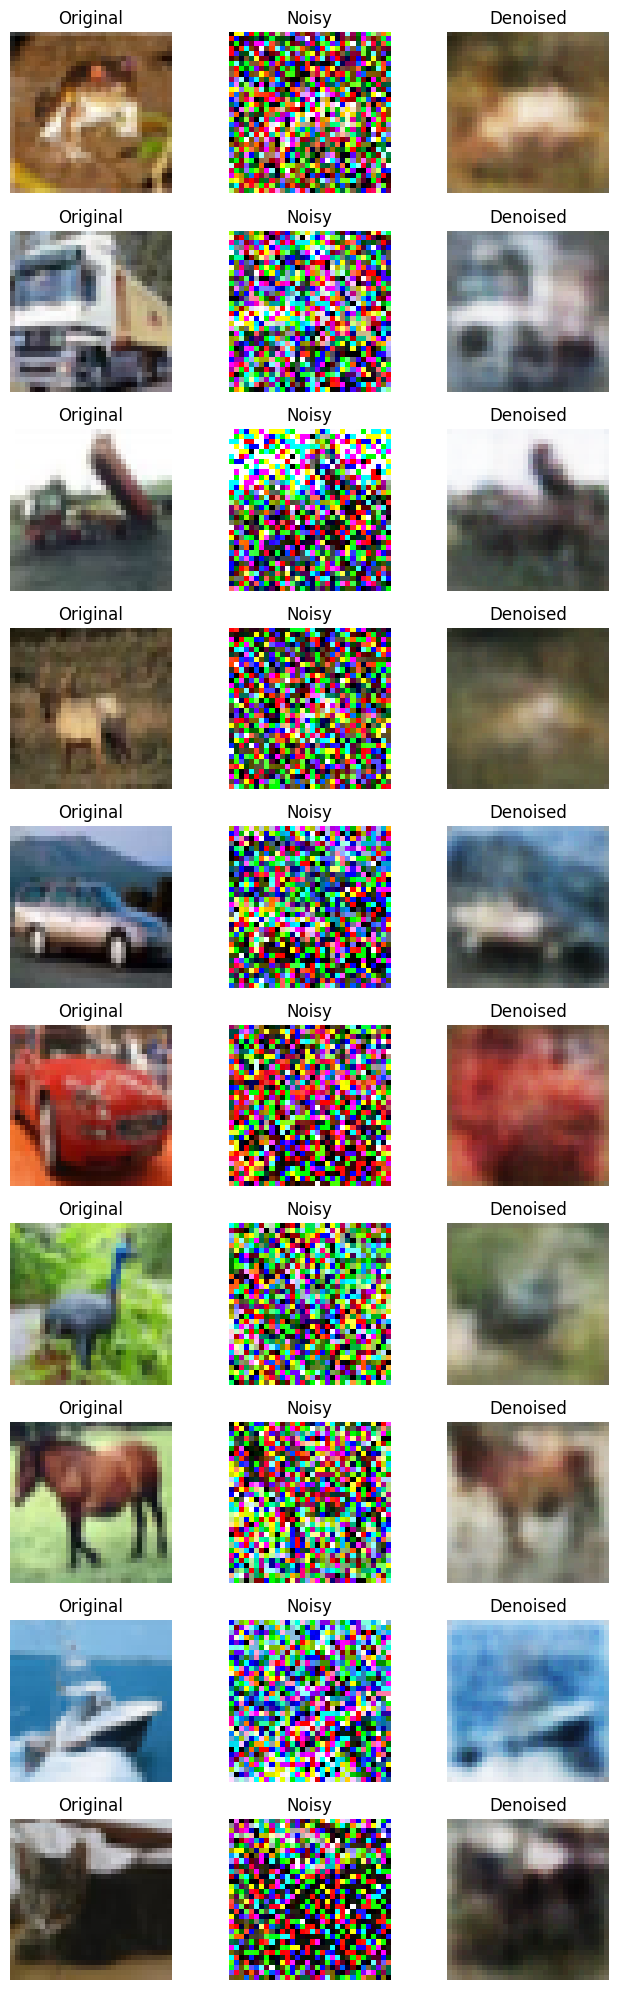

In [22]:
noise_levels = [0.05, 0.1, 0.2, 0.3, 0.4]
model = Autoencoder(latent_dim=128)
device = "cpu"
for noise in noise_levels:

    print("Training with noise:", noise)

    train_denoising(model, loader, noise_ratio=noise)

    show_results(model, cifar_train, noise)

### Repeat w/MNIST

In [46]:
def mnist_to_rgb(img):
    if img.dim() == 3:      # single image: [1, H, W]
        return img.repeat(3, 1, 1)
    elif img.dim() == 4:    # batch: [B, 1, H, W]
        return img.repeat(1, 3, 1, 1)
    else:
        raise ValueError(f"Unexpected image shape: {img.shape}")

def train_denoising(model, loader, noise_ratio=0.1, epochs=30):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0
        total_samples = 0

        for x, _ in loader:
            x = mnist_to_rgb(x)
            clean = x.to(device)
            
            noisy_list = []
            for i in range(clean.size(0)):
                np_img = (clean[i].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
                noisy_np = add_noise_cifar(np_img, noise_ratio)

                noisy_t = torch.from_numpy(noisy_np).permute(2,0,1).float() / 255.0
                noisy_list.append(noisy_t)

            noisy = torch.stack(noisy_list).to(device)

            recon = model(noisy)
            loss = criterion(recon, clean)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # accumulate loss correctly
            batch_size = clean.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

        print(f"Epoch {epoch+1}, Loss: {total_loss/total_samples:.6f}")

In [47]:
def show_results(model, dataset, noise_ratio, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    fig, axes = plt.subplots(10, 3, figsize=(7, 20))

    for i in range(10):
        img, _ = dataset[i]  
        img = mnist_to_rgb(img) 

        # convert to numpy HWC for noise
        clean_np = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        noisy_np = add_noise_cifar(clean_np, noise_ratio)

        # back to tensor for model
        noisy_tensor = torch.from_numpy(noisy_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
        noisy_tensor = noisy_tensor.to(device)

        with torch.no_grad():
            denoised = model(noisy_tensor)[0].cpu()  

        axes[i,0].imshow(img.permute(1,2,0))
        axes[i,0].set_title("Original")
        axes[i,0].axis("off")

        axes[i,1].imshow(noisy_np)
        axes[i,1].set_title("Noisy")
        axes[i,1].axis("off")

        axes[i,2].imshow(denoised.permute(1,2,0).clamp(0,1))
        axes[i,2].set_title("Denoised")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.show()

## Train

Training with noise: 0.05
Epoch 1, Loss: 0.074619
Epoch 2, Loss: 0.050238
Epoch 3, Loss: 0.030835
Epoch 4, Loss: 0.016696
Epoch 5, Loss: 0.011173
Epoch 6, Loss: 0.008543
Epoch 7, Loss: 0.007029
Epoch 8, Loss: 0.005999
Epoch 9, Loss: 0.005236
Epoch 10, Loss: 0.004660
Epoch 11, Loss: 0.004275
Epoch 12, Loss: 0.003970
Epoch 13, Loss: 0.003727
Epoch 14, Loss: 0.003493
Epoch 15, Loss: 0.003299
Epoch 16, Loss: 0.003135
Epoch 17, Loss: 0.003042
Epoch 18, Loss: 0.002910
Epoch 19, Loss: 0.002809
Epoch 20, Loss: 0.002717
Epoch 21, Loss: 0.002613
Epoch 22, Loss: 0.002565
Epoch 23, Loss: 0.002499
Epoch 24, Loss: 0.002415
Epoch 25, Loss: 0.002331
Epoch 26, Loss: 0.002276
Epoch 27, Loss: 0.002206
Epoch 28, Loss: 0.002190
Epoch 29, Loss: 0.002138
Epoch 30, Loss: 0.002081


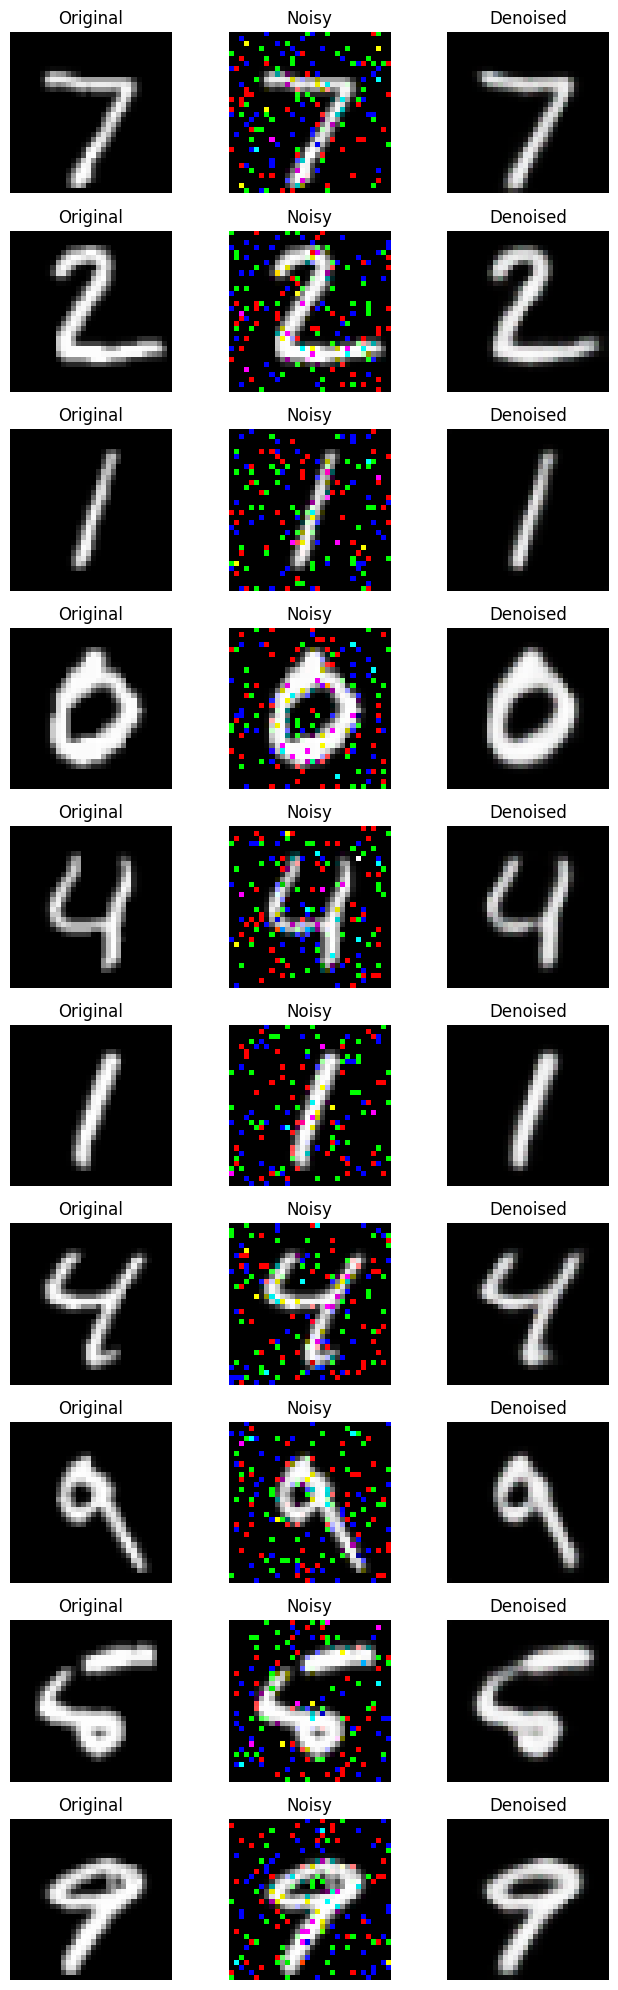

Training with noise: 0.1
Epoch 1, Loss: 0.085117
Epoch 2, Loss: 0.052976
Epoch 3, Loss: 0.043484
Epoch 4, Loss: 0.026513
Epoch 5, Loss: 0.017568
Epoch 6, Loss: 0.012494
Epoch 7, Loss: 0.010034
Epoch 8, Loss: 0.008485
Epoch 9, Loss: 0.007282
Epoch 10, Loss: 0.006479
Epoch 11, Loss: 0.005859
Epoch 12, Loss: 0.005316
Epoch 13, Loss: 0.004952
Epoch 14, Loss: 0.004754
Epoch 15, Loss: 0.004421
Epoch 16, Loss: 0.004256
Epoch 17, Loss: 0.003975
Epoch 18, Loss: 0.003840
Epoch 19, Loss: 0.003714
Epoch 20, Loss: 0.003620
Epoch 21, Loss: 0.003477
Epoch 22, Loss: 0.003386
Epoch 23, Loss: 0.003258
Epoch 24, Loss: 0.003247
Epoch 25, Loss: 0.003162
Epoch 26, Loss: 0.003073
Epoch 27, Loss: 0.003004
Epoch 28, Loss: 0.002908
Epoch 29, Loss: 0.002838
Epoch 30, Loss: 0.002788


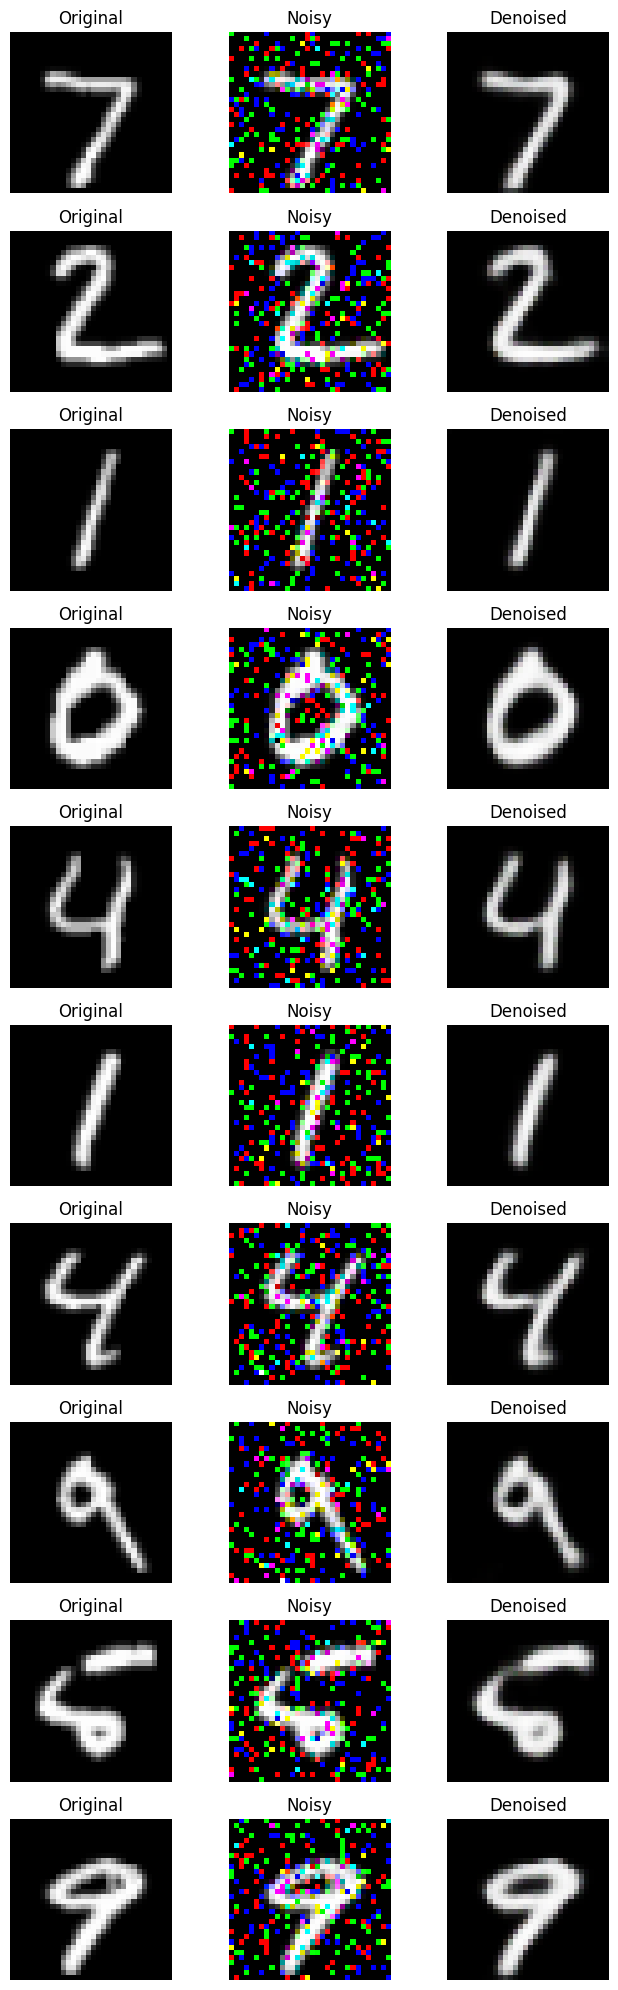

Training with noise: 0.2
Epoch 1, Loss: 0.079721
Epoch 2, Loss: 0.052876
Epoch 3, Loss: 0.039570
Epoch 4, Loss: 0.023176
Epoch 5, Loss: 0.015460
Epoch 6, Loss: 0.011877
Epoch 7, Loss: 0.009987
Epoch 8, Loss: 0.008720
Epoch 9, Loss: 0.007730
Epoch 10, Loss: 0.007099
Epoch 11, Loss: 0.006611
Epoch 12, Loss: 0.006151
Epoch 13, Loss: 0.005919
Epoch 14, Loss: 0.005551
Epoch 15, Loss: 0.005387
Epoch 16, Loss: 0.005185
Epoch 17, Loss: 0.005024
Epoch 18, Loss: 0.004823
Epoch 19, Loss: 0.004721
Epoch 20, Loss: 0.004605
Epoch 21, Loss: 0.004469
Epoch 22, Loss: 0.004336
Epoch 23, Loss: 0.004335
Epoch 24, Loss: 0.004201
Epoch 25, Loss: 0.004084
Epoch 26, Loss: 0.004017
Epoch 27, Loss: 0.003982
Epoch 28, Loss: 0.003876
Epoch 29, Loss: 0.003818
Epoch 30, Loss: 0.003796


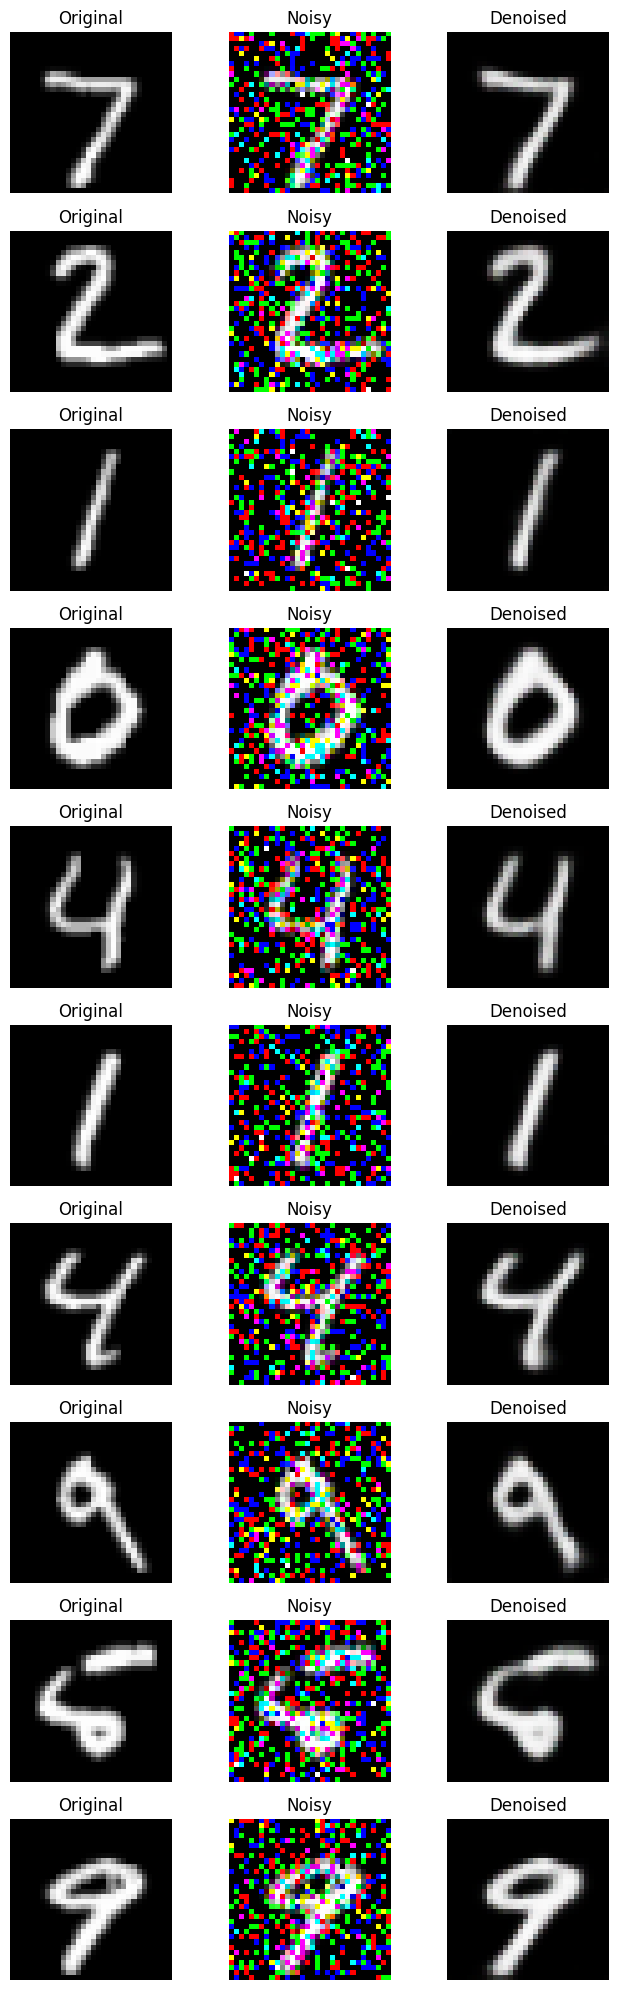

Training with noise: 0.3
Epoch 1, Loss: 0.087525
Epoch 2, Loss: 0.054310
Epoch 3, Loss: 0.049853
Epoch 4, Loss: 0.038056
Epoch 5, Loss: 0.026233
Epoch 6, Loss: 0.019319
Epoch 7, Loss: 0.015305
Epoch 8, Loss: 0.013016
Epoch 9, Loss: 0.011601
Epoch 10, Loss: 0.010583
Epoch 11, Loss: 0.009627
Epoch 12, Loss: 0.009089
Epoch 13, Loss: 0.008571
Epoch 14, Loss: 0.008112
Epoch 15, Loss: 0.007775
Epoch 16, Loss: 0.007444
Epoch 17, Loss: 0.007187
Epoch 18, Loss: 0.007024
Epoch 19, Loss: 0.006788
Epoch 20, Loss: 0.006643
Epoch 21, Loss: 0.006530
Epoch 22, Loss: 0.006303
Epoch 23, Loss: 0.006233
Epoch 24, Loss: 0.006136
Epoch 25, Loss: 0.005972
Epoch 26, Loss: 0.005919
Epoch 27, Loss: 0.005937
Epoch 28, Loss: 0.005811
Epoch 29, Loss: 0.005639
Epoch 30, Loss: 0.005610


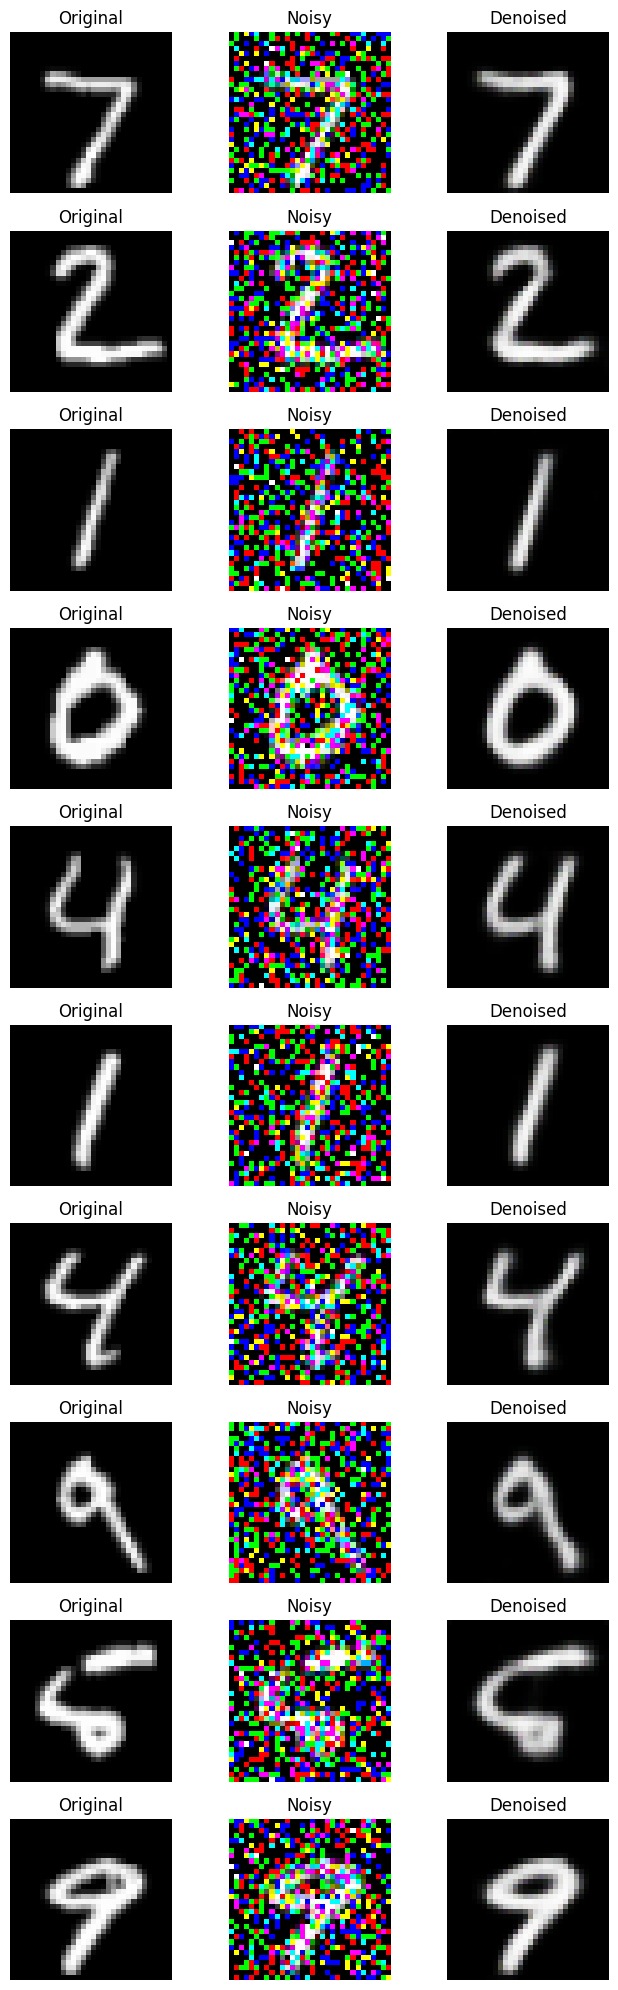

Training with noise: 0.4
Epoch 1, Loss: 0.076346
Epoch 2, Loss: 0.054777
Epoch 3, Loss: 0.045314
Epoch 4, Loss: 0.028933
Epoch 5, Loss: 0.020034
Epoch 6, Loss: 0.016072
Epoch 7, Loss: 0.013977
Epoch 8, Loss: 0.012449
Epoch 9, Loss: 0.011554
Epoch 10, Loss: 0.010849
Epoch 11, Loss: 0.010355
Epoch 12, Loss: 0.009824
Epoch 13, Loss: 0.009454
Epoch 14, Loss: 0.009187
Epoch 15, Loss: 0.008930
Epoch 16, Loss: 0.008707
Epoch 17, Loss: 0.008584
Epoch 18, Loss: 0.008218
Epoch 19, Loss: 0.008185
Epoch 20, Loss: 0.008082
Epoch 21, Loss: 0.007784
Epoch 22, Loss: 0.007641
Epoch 23, Loss: 0.007691
Epoch 24, Loss: 0.007518
Epoch 25, Loss: 0.007380
Epoch 26, Loss: 0.007317
Epoch 27, Loss: 0.007209
Epoch 28, Loss: 0.007135
Epoch 29, Loss: 0.007098
Epoch 30, Loss: 0.006891


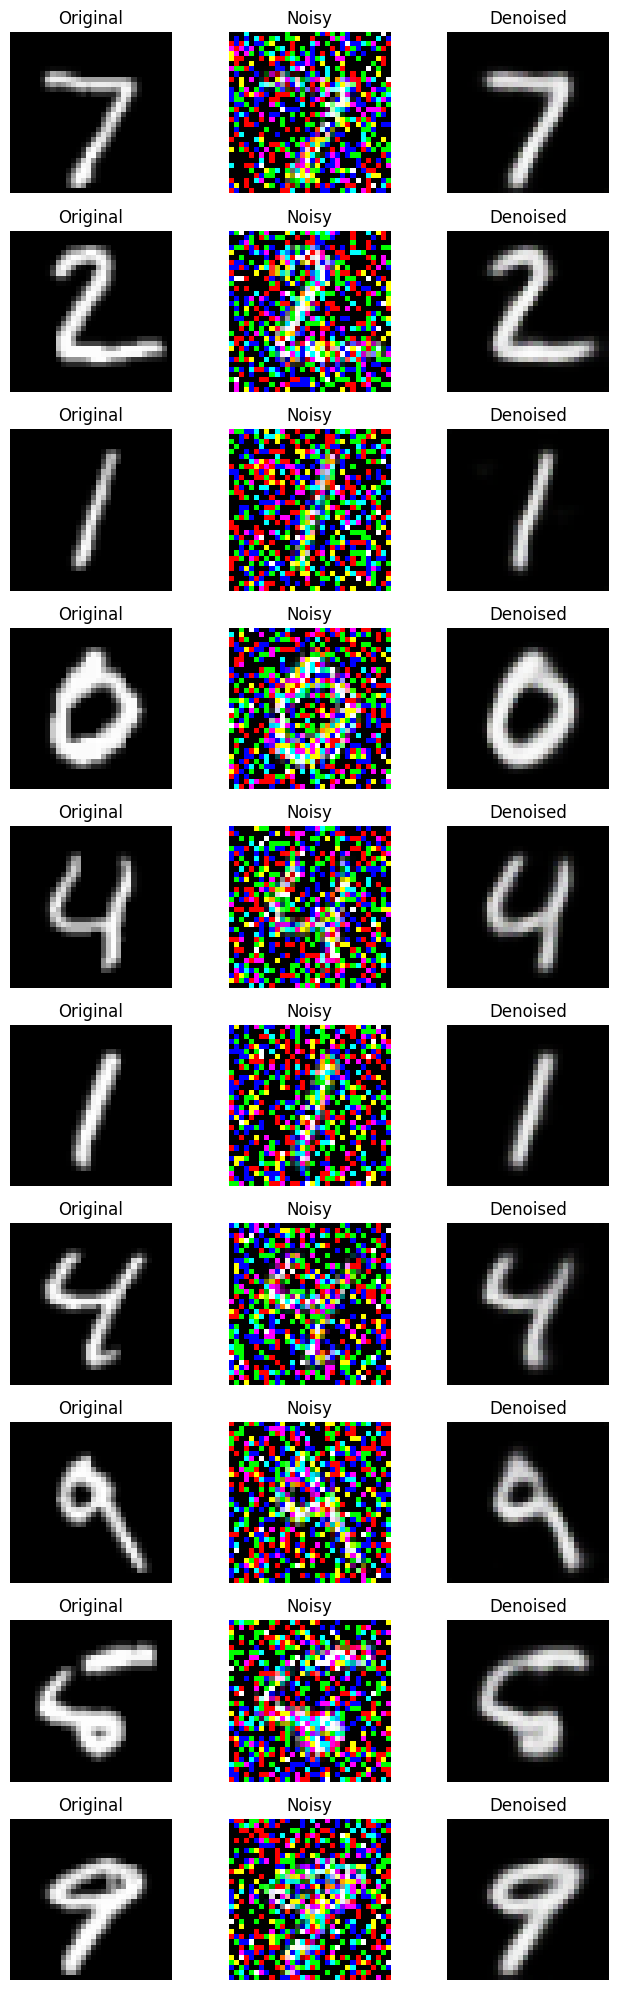

In [48]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

mnist = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

mnist_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

indices = np.random.choice(len(mnist), 5000, replace=False)
mnist_subset = Subset(mnist, indices)

mnist_loader = DataLoader(
    mnist_subset,
    batch_size=64,
    shuffle=True
)

for noise in noise_levels:
    print("Training with noise:", noise)

    model = Autoencoder().to(device)
    train_denoising(model, mnist_loader, noise_ratio=noise)

    show_results(model, mnist_test, noise)

# Part 4

### Previous Model

In [60]:
transform = transforms.Compose([
 transforms.ToTensor()
 ])
 
 trainset = torchvision.datasets.MNIST(
 root="./data",
 train=True,
 download=True,
 transform=transform
 )
 
 testset = torchvision.datasets.MNIST(
 root="./data",
 train=False,
 download=True,
 transform=transform
 )
 
 trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
 testloader = DataLoader(testset, batch_size=64, shuffle=False)
 
 class Net2FC(nn.Module):
    def __init__(self, activation="relu"):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)
    
        if activation == "relu":
            self.act = F.relu
        elif activation == "sigmoid":
            self.act = torch.sigmoid
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x
    
 device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 net = Net2FC().to(device)
 criterion = nn.CrossEntropyLoss()
 optimizer = torch.optim.SGD(net.parameters(), lr=0.1, momentum=0)

In [61]:
target_counts = {
    9: 10,
    8: 20,
    7: 40,
    6: 80,
    5: 160,
    4: 320,
    3: 640,
    2: 1000,
    1: 1000,
    0: 1000
 }
 
 targets = np.array(testset.targets)
 selected_indices = []
 
 for digit in [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]:
    digit_indices = np.where(targets == digit)[0]
    count = target_counts[digit]
 
    replace = count > len(digit_indices)
    chosen = np.random.choice(digit_indices, count, replace=replace)
    selected_indices.extend(chosen)
 
 skewed_test_dataset = Subset(testset, selected_indices)
 skewed_testloader = DataLoader(skewed_test_dataset, batch_size=64, shuffle=False)

In [58]:
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
    
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
        
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

In [ ]:
for epoch in range(20):
    net.train()
    running_loss = 0.0
    
    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
 
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(trainloader):.4f}")
 
 
correct = 0
total = 0

acc = evaluate_accuracy(net, skewed_testloader, device)
print(f"Skewed test accuracy: {acc:.2f}%")